Saving archive.zip to archive (1).zip
Accuracy: 0.9704035874439462


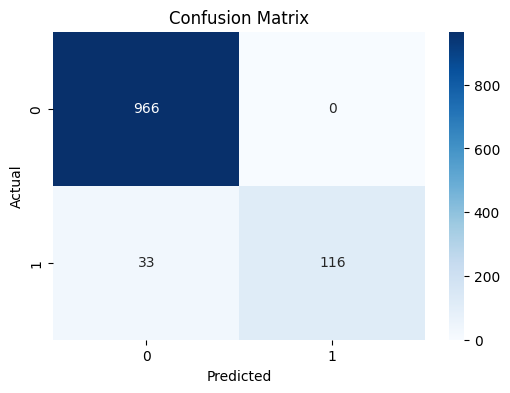


Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [2]:
!pip install scikit-learn seaborn

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from google.colab import files

# 1. Upload & Load Dataset
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0], encoding='latin-1')

# 2. Data Preprocessing
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
df.dropna(inplace=True)

# 3. Train-Test Split
X = df['message']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. TF-IDF Vectorization
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 5. Train Logistic Regression Model
model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

# 6. Predictions
y_pred = model.predict(X_test_tfidf)

# 7. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# 8. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 9. Classification Report (Precision, Recall, F1)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
